In [1]:
import pandas as pd

df = pd.read_csv('data\\Application_with_features_consolidated.csv')
len(df)

116

# General

In [3]:
df.describe()

,score,price,AI_maturity
count,116.000000,116.000000,116.000000
mean,3.324849,0.047328,1.577586
std,1.653330,0.509734,0.835629
min,0.000000,0.000000,1.000000
25%,2.878517,0.000000,1.000000
50%,4.074654,0.000000,1.000000
75%,4.547075,0.000000,2.000000
max,5.000000,5.490000,4.000000


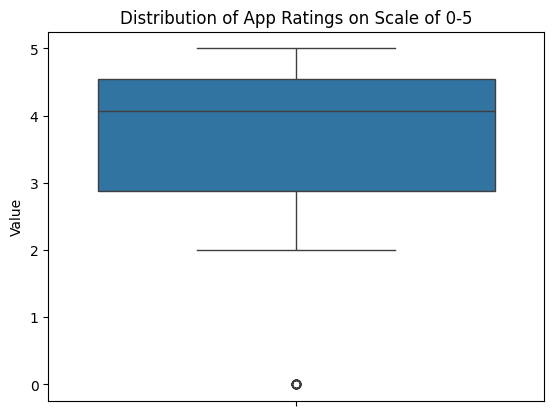

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the violin plot
sns.boxplot(y=df['score'])
fig_folder = 'figures'
# Add labels and show
plt.title('Distribution of App Ratings on Scale of 0-5')
plt.ylabel('Value')
plt.savefig(fig_folder + "/AppRatingDistribution.pdf", format='pdf',  bbox_inches='tight')
plt.show()


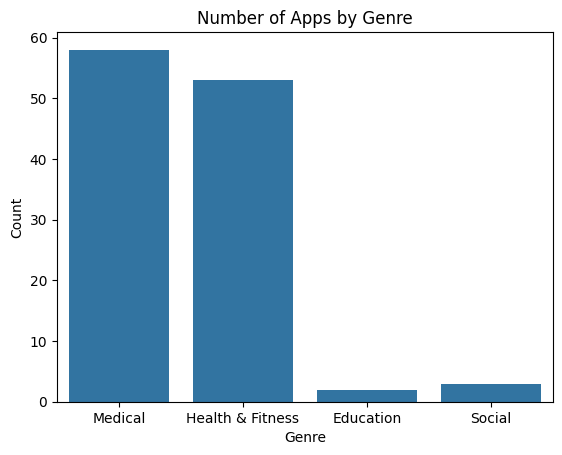

In [5]:

# Create the bar plot
sns.countplot(x='genre', data=df)

# Add labels and show
plt.title('Number of Apps by Genre')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.savefig(fig_folder + "/GenreDistribution.pdf", format='pdf',  bbox_inches='tight')
plt.show()

In [6]:
df[df["price"]!=0.0] ## Most apps are free to download. 

,appId,title,score,genre,price,free,description,developer,installs,keyword,country,uncleaned_LLM_features,features_processed,consolidated_features,AI_maturity
99,com.lcs.mmp.full,Manage My Pain Pro,4.433962,Medical,5.49,False,Don't let chronic pain stop you from living yo...,"ManagingLife, Inc.","10,000+",Chronic disease management,ca,"['track pain and activity', 'analyze pain patt...","['track pain activity', 'analyze pain pattern'...","['share pain report', 'unlock advanced report'...",2


In [7]:
len(list(set(list(df["developer"]))))

112

In [8]:
df[df.duplicated(subset='developer', keep=False)].sort_values(by='developer', ascending=True)

,appId,title,score,genre,price,free,description,developer,installs,keyword,country,uncleaned_LLM_features,features_processed,consolidated_features,AI_maturity
28,org.communitymedical.cch,CCH Health,0.000000,Health & Fitness,0.00,True,A mobile app for Community Care Health members...,CMC Community Medical Centers,500+,Healthcare community,us,"['access claims information', 'view patient ch...","['access claim information', 'view patient cha...","['manage claim', 'access patient information',...",1
30,org.communitymedical.cmc,MyHealthMate,4.105263,Medical,0.00,True,This app provides quick and easy access to you...,CMC Community Medical Centers,"5,000+",Healthcare community,us,"['access medical records', 'important resource...","['access medical record', 'important resource ...","['access medical record', 'medical emergency',...",1
27,com.caremarket.communitycareexplorer.prod,Sydney Community,4.285714,Medical,0.00,True,Sydney Community provides support when you nee...,"Elevance Health, Inc.","5,000+",Healthcare community,us,"['connect with others', 'share your story', 'c...","['connect others', 'share story', 'comment pos...","['share knowledge', 'connect others', 'browse ...",1
62,com.anthem.sydney,Sydney Health,4.698271,Medical,0.00,True,Use the Sydney<sub>SM</sub> Health app to find...,"Elevance Health, Inc.","1,000,000+",Health management,us,"['digital id card', '24/7 chat', 'plan details...","['digital id card', '247 chat', 'plan detail',...","['estimated cost', 'automatic refill', 'remind...",1
63,com.lcs.mmp.lite,Manage My Pain,4.575221,Medical,0.00,True,Don't let chronic pain stop you from living yo...,"ManagingLife, Inc.","100,000+",Health management,us,"['track pain and activity', 'analyze pain patt...","['track pain activity', 'analyze pain pattern'...","['share pain report', 'track pain activity', '...",2
99,com.lcs.mmp.full,Manage My Pain Pro,4.433962,Medical,5.49,False,Don't let chronic pain stop you from living yo...,"ManagingLife, Inc.","10,000+",Chronic disease management,ca,"['track pain and activity', 'analyze pain patt...","['track pain activity', 'analyze pain pattern'...","['share pain report', 'unlock advanced report'...",2
29,com.CHN.quiz,Community Health Nursing,0.000000,Education,0.00,True,This app Contain Following Topics\r\n\tVaccin...,Nursing Study,"10,000+",Healthcare community,us,"['vaccination information', 'cold chain manage...","['vaccination information', 'cold chain manage...","['provide health data', 'vital health statisti...",1
34,com.firstyeargnm.communityhn,GNM - Community Health Nursing,0.000000,Education,0.00,True,This App Contain Following Topics\r\n1.Long Qu...,Nursing Study,"10,000+",Healthcare community,us,"['community health nursing notes', 'disease cy...","['community health nursing note', 'disease cyc...","['cooking principle', 'planned parenthood', 'r...",1


112 unique developers and 4 developers publish two apps while the rest publish only one

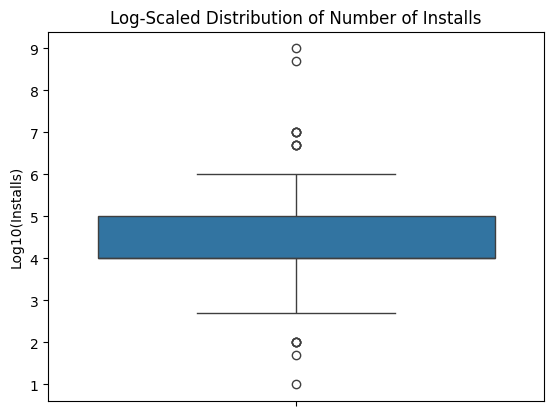

In [9]:
import numpy as np

df['downloads_clean'] = df['installs'].str.replace(',', '').str.replace('+', '').astype(int)

# Create a log-transformed column (use natural log or log10 depending on context)
df['log_downloads'] = np.log10(df['downloads_clean'])

# Plot boxplot of log-transformed downloads
sns.boxplot(y=df['log_downloads'])

# Labels
plt.title('Log-Scaled Distribution of Number of Installs')
plt.ylabel('Log10(Installs)')
plt.savefig(fig_folder + "/logdistributionInstalls.pdf", format='pdf',  bbox_inches='tight')
plt.show()


In [10]:
df.describe()

,score,price,AI_maturity,downloads_clean,log_downloads
count,116.000000,116.000000,116.000000,1.160000e+02,116.000000
mean,3.324849,0.047328,1.577586,1.360568e+07,4.531621
std,1.653330,0.509734,0.835629,1.033795e+08,1.376066
min,0.000000,0.000000,1.000000,1.000000e+01,1.000000
25%,2.878517,0.000000,1.000000,1.000000e+04,4.000000
50%,4.074654,0.000000,1.000000,1.000000e+04,4.000000
75%,4.547075,0.000000,2.000000,1.000000e+05,5.000000
max,5.000000,5.490000,4.000000,1.000000e+09,9.000000


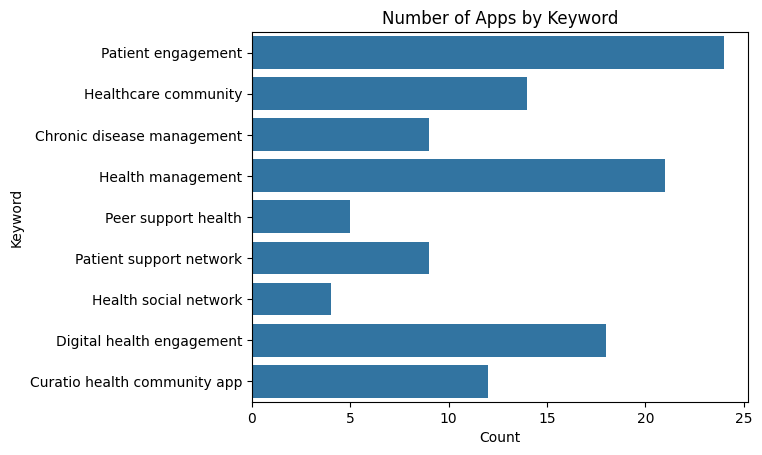

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the horizontal bar plot
sns.countplot(y='keyword', data=df)

# Add labels
plt.title('Number of Apps by Keyword')
plt.xlabel('Count')
plt.ylabel('Keyword')
plt.savefig(fig_folder + "/keywordDistribution.pdf", format='pdf',  bbox_inches='tight')
# Show plot
plt.show()


# AI maturity

In [13]:
df['AI_maturity'].value_counts()

AI_maturity
1    70
2    30
3    11
4     5
Name: count, dtype: int64

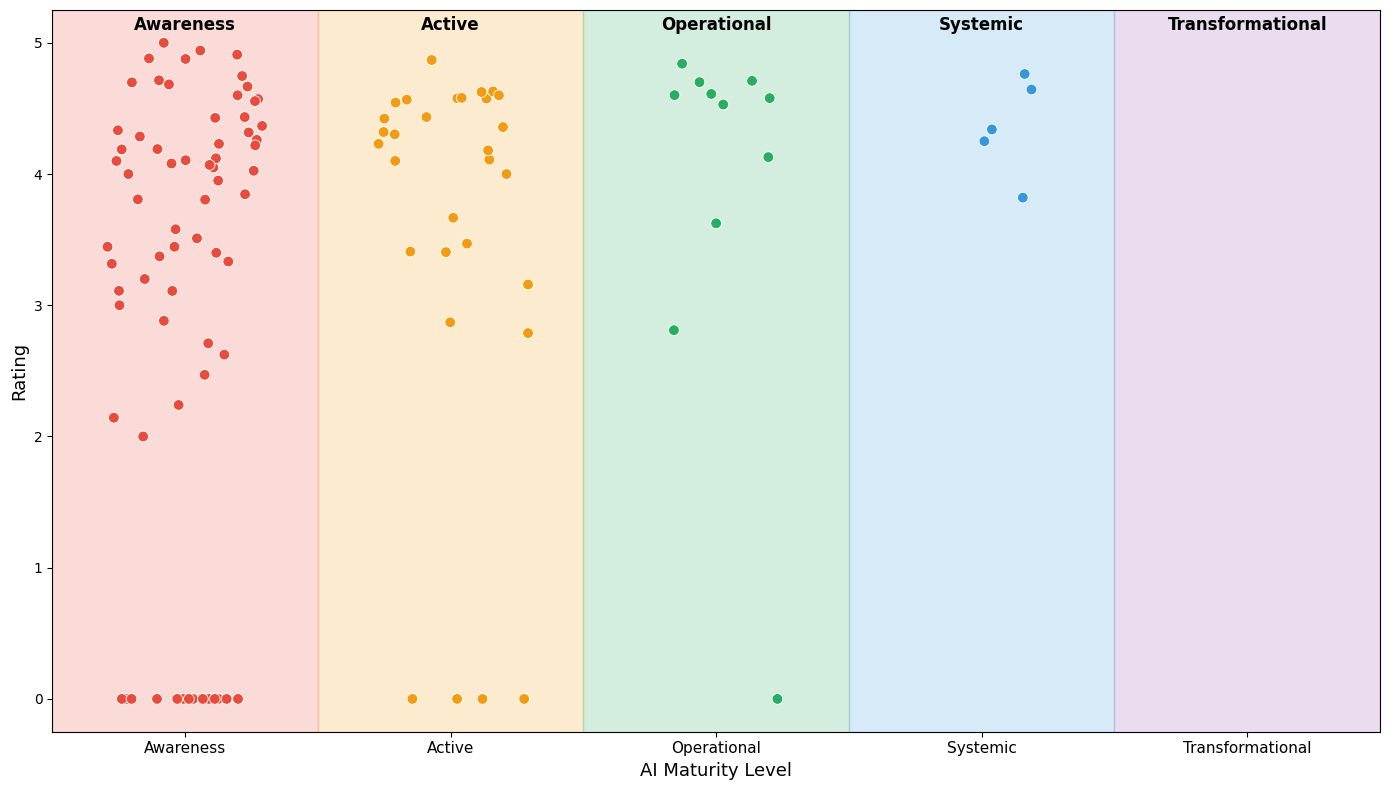

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define labels and colors corresponding to numeric levels
maturity_labels = {
    1: "Awareness",
    2: "Active",
    3: "Operational",
    4: "Systemic",
    5: "Transformational"
}
colors = ['#e74c3c', '#f39c12', '#27ae60', '#3498db', '#9b59b6']

# Set up the plot
plt.figure(figsize=(14, 8))
ax = plt.gca()

# Shade background zones
for i in range(1, 6):
    ax.axvspan(i - 0.5, i + 0.5, color=colors[i - 1], alpha=0.2)
    ax.text(i, df['score'].max() + 0.1, maturity_labels[i], ha='center', fontsize=12, fontweight='bold')

# Add jitter to x values to prevent overlapping
jittered_x = df['AI_maturity'] + np.random.uniform(-0.3, 0.3, size=len(df))

# Scatter plot
sns.scatterplot(
    x=jittered_x,
    y=df['score'],
    hue=df['AI_maturity'],
    palette=dict(zip(range(1, 6), colors)),
    legend=False,
    s=60
)

# Customize the plot
ax.set_xticks(range(1, 6))
ax.set_xticklabels([maturity_labels[i] for i in range(1, 6)], fontsize=11)
ax.set_xlabel("AI Maturity Level", fontsize=13)
ax.set_ylabel("Rating", fontsize=13)
# ax.set_title("AI Maturity Level vs Score", fontsize=15, fontweight='bold')
ax.set_xlim(0.5, 5.5)
plt.tight_layout()
plt.savefig(fig_folder + "/AIMaturityVSRating.pdf", format='pdf',  bbox_inches='tight')
plt.show()


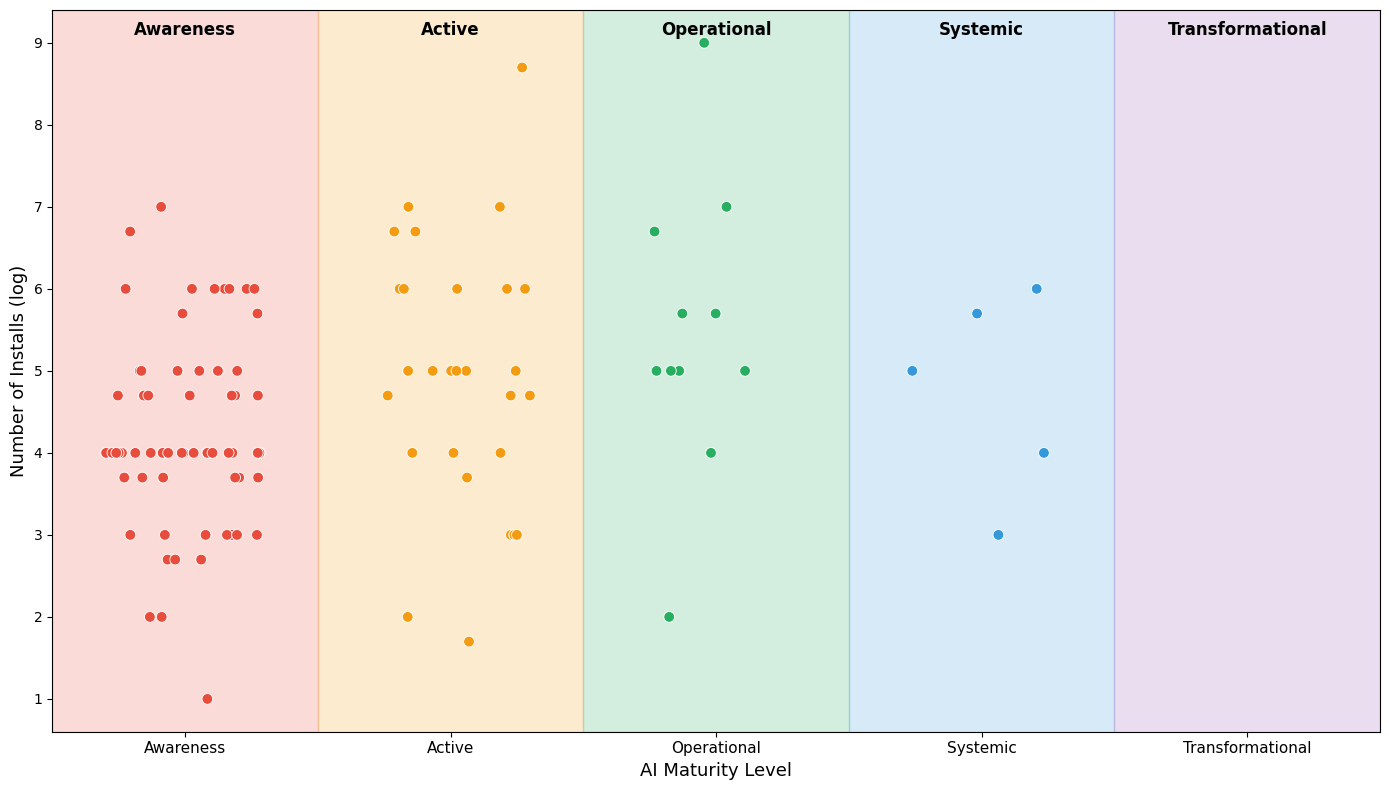

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define labels and colors corresponding to numeric levels
maturity_labels = {
    1: "Awareness",
    2: "Active",
    3: "Operational",
    4: "Systemic",
    5: "Transformational"
}
colors = ['#e74c3c', '#f39c12', '#27ae60', '#3498db', '#9b59b6']

# Set up the plot
plt.figure(figsize=(14, 8))
ax = plt.gca()

# Shade background zones
for i in range(1, 6):
    ax.axvspan(i - 0.5, i + 0.5, color=colors[i - 1], alpha=0.2)
    ax.text(i, df['log_downloads'].max() + 0.1, maturity_labels[i], ha='center', fontsize=12, fontweight='bold')

# Add jitter to x values to prevent overlapping
jittered_x = df['AI_maturity'] + np.random.uniform(-0.3, 0.3, size=len(df))

# Scatter plot
sns.scatterplot(
    x=jittered_x,
    y=df['log_downloads'],
    hue=df['AI_maturity'],
    palette=dict(zip(range(1, 6), colors)),
    legend=False,
    s=60
)

# Customize the plot
ax.set_xticks(range(1, 6))
ax.set_xticklabels([maturity_labels[i] for i in range(1, 6)], fontsize=11)
ax.set_xlabel("AI Maturity Level", fontsize=13)
ax.set_ylabel("Number of Installs (log)", fontsize=13)
# ax.set_title("AI Maturity Level vs Score", fontsize=15, fontweight='bold')
ax.set_xlim(0.5, 5.5)
plt.tight_layout()
plt.savefig(fig_folder + "/AIMaturityVSloginstalls.pdf", format='pdf',  bbox_inches='tight')
plt.show()

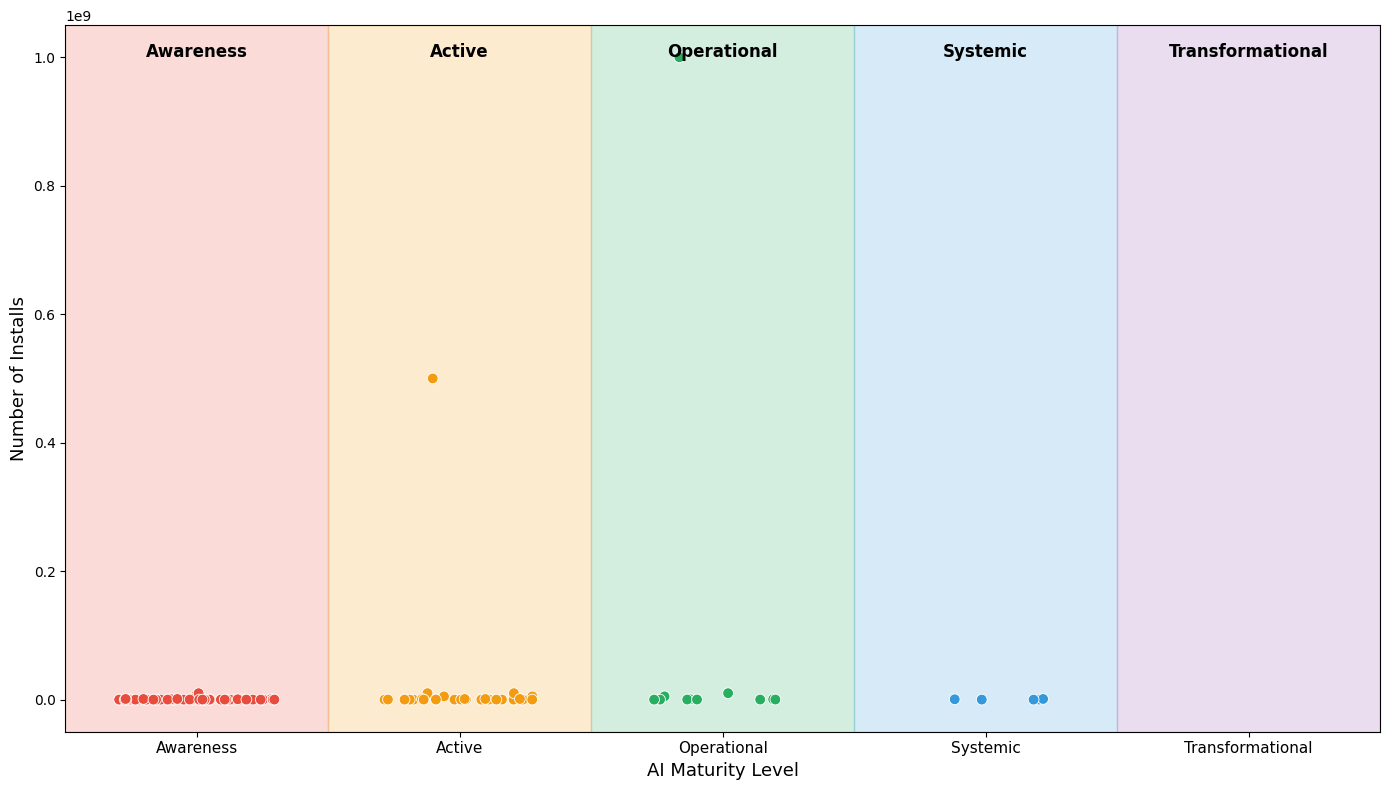

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define labels and colors corresponding to numeric levels
maturity_labels = {
    1: "Awareness",
    2: "Active",
    3: "Operational",
    4: "Systemic",
    5: "Transformational"
}
colors = ['#e74c3c', '#f39c12', '#27ae60', '#3498db', '#9b59b6']

# Set up the plot
plt.figure(figsize=(14, 8))
ax = plt.gca()

# Shade background zones
for i in range(1, 6):
    ax.axvspan(i - 0.5, i + 0.5, color=colors[i - 1], alpha=0.2)
    ax.text(i, df['downloads_clean'].max() + 0.1, maturity_labels[i], ha='center', fontsize=12, fontweight='bold')

# Add jitter to x values to prevent overlapping
jittered_x = df['AI_maturity'] + np.random.uniform(-0.3, 0.3, size=len(df))

# Scatter plot
sns.scatterplot(
    x=jittered_x,
    y=df['downloads_clean'],
    hue=df['AI_maturity'],
    palette=dict(zip(range(1, 6), colors)),
    legend=False,
    s=60
)

# Customize the plot
ax.set_xticks(range(1, 6))
ax.set_xticklabels([maturity_labels[i] for i in range(1, 6)], fontsize=11)
ax.set_xlabel("AI Maturity Level", fontsize=13)
ax.set_ylabel("Number of Installs", fontsize=13)
# ax.set_title("AI Maturity Level vs Score", fontsize=15, fontweight='bold')
ax.set_xlim(0.5, 5.5)
plt.tight_layout()
plt.savefig(fig_folder + "/AIMaturityVSinstalls.pdf", format='pdf',  bbox_inches='tight')
plt.show()

In [20]:
df_corr = df[['score', 'AI_maturity', 'log_downloads']]
df_corr

,score,AI_maturity,log_downloads
0,3.445820,1,6.00000
1,4.600000,1,3.00000
2,4.316832,1,5.00000
3,2.000000,1,4.00000
4,3.804878,1,4.00000
...,...,...,...
111,2.470000,1,4.69897
112,3.846154,1,6.00000
113,4.625000,2,3.69897
114,4.320000,2,5.00000


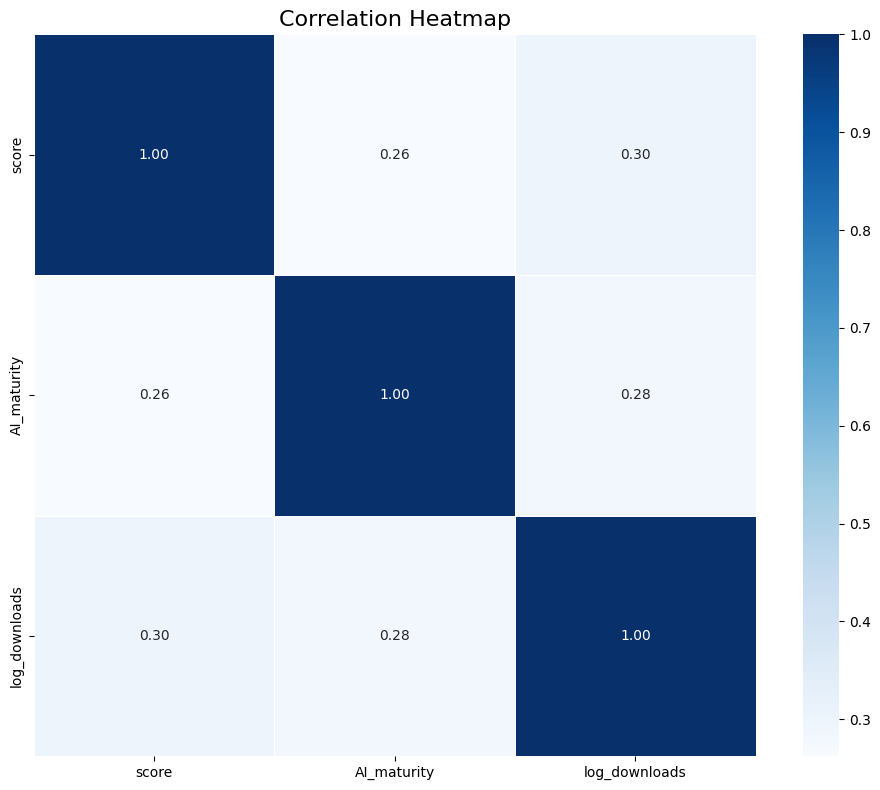

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
corr = df_corr.corr(numeric_only=True, method='spearman')  # Optional: Use numeric_only=True to skip categorical columns

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='Blues', square=True, linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.savefig(fig_folder + "/corr.pdf", format='pdf',  bbox_inches='tight')
plt.show()


# Feature Analysis

In [30]:
import pandas as pd
import ast

# Convert string to list
df['consolidated_features'] = df['consolidated_features'].apply(ast.literal_eval)

# Calculate number of features per app
df['num_features'] = df['consolidated_features'].apply(len)

# Get statistics
min_features = df['num_features'].min()
max_features = df['num_features'].max()
avg_features = df['num_features'].mean()

print(f"Minimum number of features: {min_features}")
print(f"Maximum number of features: {max_features}")
print(f"Average number of features: {avg_features:.2f}")


Minimum number of features: 1
Maximum number of features: 38
Average number of features: 11.12


In [33]:
from collections import Counter
import pandas as pd
import ast

# Convert stringified lists to actual lists if not done already
# df['consolidated_features'] = df['consolidated_features'].apply(ast.literal_eval)

# Flatten all features into a single list
all_features = [feature for sublist in df['consolidated_features'] for feature in sublist]

# Count the occurrences of each feature
feature_counts = Counter(all_features)

# Create a DataFrame from the counter
feature_df = pd.DataFrame(feature_counts.items(), columns=['feature', 'count'])

# Optional: sort by count descending
feature_df = feature_df.sort_values(by='count', ascending=False).reset_index(drop=True)

feature_df.head(10)

,feature,count
0,provide health data,21
1,access medical record,14
2,view medication,10
3,symptom tracking,9
4,schedule upcoming appointment,9
5,request prescription refill,8
6,message care team,7
7,view test result,7
8,secure data storage,6
9,appointment management,6


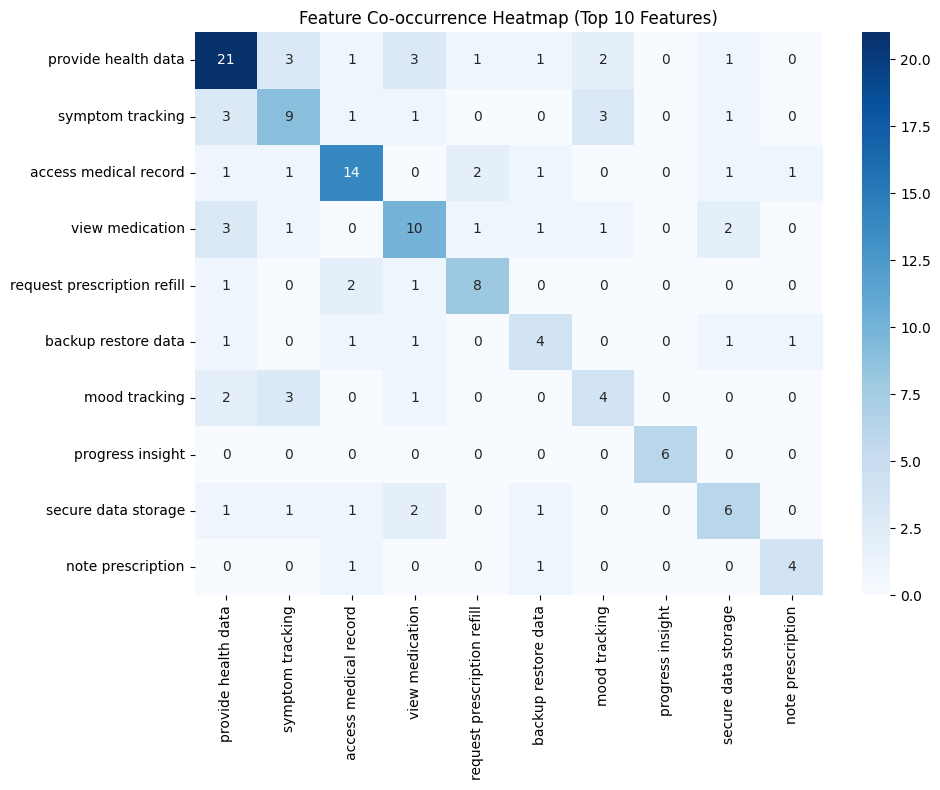

In [44]:
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Binarize features (rows = apps, columns = features, values = 1/0)
mlb = MultiLabelBinarizer()
feature_matrix = mlb.fit_transform(df['consolidated_features'])
feature_names = mlb.classes_

# Step 3: Compute co-occurrence matrix
co_matrix = (feature_matrix.T @ feature_matrix)  # (features x features)

# Step 4: Convert to DataFrame for readability
co_df = pd.DataFrame(co_matrix, index=feature_names, columns=feature_names)

# Optional: Plot heatmap (you can slice top N features to avoid clutter)
top_n = 10
top_features = co_df.sum().sort_values(ascending=False).head(top_n).index
plt.figure(figsize=(10, 8))  # Adjust width and height as needed
sns.heatmap(co_df.loc[top_features, top_features], cmap='Blues', annot=True, fmt='d')
plt.title('Feature Co-occurrence Heatmap (Top 10 Features)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('figures\\feature_cooccurrence_heatmap.pdf', dpi=300)  
plt.show()


In [36]:
pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------------------------------- -------- 1.0/1.4 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 3.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import ast



# Step 2: Transaction Encoder (convert list of features to binary format)
te = TransactionEncoder()
te_ary = te.fit(df['consolidated_features']).transform(df['consolidated_features'])
feature_df_bin = pd.DataFrame(te_ary, columns=te.columns_)

# Step 3: Mine frequent itemsets — use lower support (e.g., 0.01 = 1%)
frequent_itemsets = apriori(feature_df_bin, min_support=0.01, use_colnames=True)

print(f"Found {len(frequent_itemsets)} frequent itemsets")
print(frequent_itemsets.head())


Found 433 frequent itemsets
    support                                itemsets
0  0.017241                   (15 tracker included)
1  0.051724                            (247 access)
2  0.017241                              (247 care)
3  0.017241  (access electronic health information)
4  0.120690                 (access medical record)


In [57]:
# Step 4: Generate association rules
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# Optional: Filter strong rules
strong_rules = rules[(rules['confidence'] >= 0.5) & (rules['lift'] >= 1.0)]

# print(f"Found {len(strong_rules)} strong rules")
# strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20)

# Sort the association rules by support in descending order
rules_sorted = strong_rules.sort_values(by='support', ascending=False)

# Display the top rules
rules_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head()



,antecedents,consequents,support,confidence,lift
20,(schedule upcoming appointment),(access medical record),0.043103,0.555556,4.603175
214,(message care team),(view test result),0.034483,0.571429,9.469388
215,(view test result),(message care team),0.034483,0.571429,9.469388
298,(symptom checker),(symptom tracking),0.034483,0.800000,10.311111
43,(note prescription),(appointment management),0.025862,0.750000,14.500000


In [58]:
len(rules_sorted)

967